# Resolución de la tarea — `z201_Sobre_Árboles`

**Materia:** Data Mining en Economía y Finanzas · 2026
**Consigna original:** `monday/z201_Sobre_Árboles.ipynb` (Alejandro Bolaños)

Este notebook copia cada consigna tal como está en el original y, debajo, la
resuelve explicando **qué se busca** en ese punto y **cómo lo resuelvo**.

Se apoya en `competencia_01_crudo.csv`, que vive en `monday/`. Los scripts sueltos
que están al lado de este notebook (`01_target.py` … `07_eda_graficos.py`) son el
mismo código, partido para poder correr cada etapa por separado.

## Preparación del entorno

Nada acá responde a la consigna todavía: son las constantes del negocio y las rutas.

Los dos números que gobiernan todo el problema:

- **`ganancia_acierto = 1.072.500`** — lo que vale retener a un cliente que se iba
- **`costo_estimulo = 27.500`** — lo que cuesta el estímulo, se acierte o no

Esa asimetría de 39 a 1 es la razón de que todo el análisis que sigue mida plata y
no porcentaje de aciertos.

In [1]:
import pathlib

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree, _tree

GANANCIA_ACIERTO = 1_072_500
COSTO_ESTIMULO = 27_500
SEMILLA = 17

DIR = pathlib.Path.cwd()
DATA = DIR.parent.parent / "monday"          # los datos viven en la carpeta de la cátedra
CRUDO = DATA / "competencia_01_crudo.csv"
PARQUET = DATA / "competencia_01.parquet"

pd.set_option("display.width", 200)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False})

print("crudo presente:", CRUDO.exists())

crudo presente: True


---

# Paso previo · el target

> **Consigna de `z101_target_sql`:**
>
> ```sql
> , null as clase_ternaria -- Reemplazar null por la lógica que genera el target
> ```

## Qué se busca

El dataset crudo **no dice quién se fue**. Solo tiene fotos mensuales: una fila por
cliente y por mes. La baja hay que deducirla de la **ausencia** — si un cliente está
en abril y no aparece en mayo, se fue.

La clase mira dos meses hacia adelante:

| clase | significado |
|---|---|
| `BAJA+1` | no está el mes que viene — ya se está yendo, es tarde |
| `BAJA+2` | está el mes que viene pero no el siguiente — **este es el que hay que cazar** |
| `CONTINUA` | sigue en los dos meses |

`BAJA+2` es el target real: es el único momento en que el cliente todavía está y se
puede hacer algo.

## Cómo lo resuelvo

Con `lead()`, una función de ventana que mira filas futuras dentro de cada cliente.
Pero antes hace falta el `cross join` entre clientes y períodos: si un cliente
simplemente **no tiene fila** en un mes, `lead()` sobre la tabla original no se entera
del hueco. Generando todas las combinaciones posibles, la ausencia se vuelve un `0`
explícito y se puede mirar.

**El detalle que hay que cuidar:** para 202107 y 202108 no hay futuro que mirar — el
dataset se corta ahí. Si eso no se maneja, `lead()` devuelve `null` y esas filas caen
en el `else` quedando marcadas `CONTINUA`. Serían **163.245 clientes mal etiquetados**,
diciéndole al modelo que siguen cuando en realidad no se sabe. Por eso van los dos
`when ... is null then null`.

In [2]:
if PARQUET.exists():
    print("ya está construido, sigo")
else:
    con = duckdb.connect()
    con.execute(f"create or replace table crudo as select * from read_csv_auto('{CRUDO}')")
    con.execute("""
    create or replace table competencia_01 as
    with periodos as (
        select distinct foto_mes from crudo
    ), clientes as (
        select distinct numero_de_cliente from crudo
    ), todo as (
        select numero_de_cliente, foto_mes from clientes cross join periodos
    ), flags as (
        select
            t.numero_de_cliente
          , t.foto_mes
          , c.* exclude (numero_de_cliente, foto_mes)
          , case when c.numero_de_cliente is null then 0 else 1 end as mes_0
          , lead(case when c.numero_de_cliente is null then 0 else 1 end, 1)
                over (partition by t.numero_de_cliente order by t.foto_mes) as mes_1
          , lead(case when c.numero_de_cliente is null then 0 else 1 end, 2)
                over (partition by t.numero_de_cliente order by t.foto_mes) as mes_2
        from todo t
        left join crudo c using (numero_de_cliente, foto_mes)
    )
    select
        * exclude (mes_0, mes_1, mes_2)
      , case
            when mes_1 is null then null      -- no hay mes+1 en la ventana
            when mes_1 = 0    then 'BAJA+1'
            when mes_2 is null then null      -- hay mes+1 pero no mes+2
            when mes_2 = 0    then 'BAJA+2'
            else 'CONTINUA'
        end as clase_ternaria
    from flags
    where mes_0 = 1
    """)
    con.execute(f"copy competencia_01 to '{PARQUET}' (format parquet)")
    print("construido")

def cargar(foto_mes=None, columnas="*"):
    where = f"where foto_mes = {foto_mes}" if foto_mes else ""
    return duckdb.sql(f"select {columnas} from '{PARQUET}' {where}").df()

ya está construido, sigo


Verificamos la cardinalidad, que es una de las preguntas del notebook original
(*¿cuál es la nominalidad de cada clase?*):

In [3]:
duckdb.sql(f"""
    select foto_mes
         , sum(clase_ternaria = 'BAJA+1')::int   as "BAJA+1"
         , sum(clase_ternaria = 'BAJA+2')::int   as "BAJA+2"
         , sum(clase_ternaria = 'CONTINUA')::int as "CONTINUA"
         , sum(clase_ternaria is null)::int      as sin_clase
         , round(100.0 * sum(clase_ternaria = 'BAJA+2') / count(*), 3) as pct_baja2
    from '{PARQUET}' group by foto_mes order by foto_mes
""").df()

,foto_mes,BAJA+1,BAJA+2,CONTINUA,sin_clase,pct_baja2
0,202103,1019,960,160921,0,0.589
1,202104,964,1139,161181,0,0.698
2,202105,1143,870,161755,0,0.531
3,202106,874,1098,162142,0,0.669
4,202107,1103,0,0,163245,0.000
5,202108,<NA>,<NA>,<NA>,164647,NaN


**Lo que muestra:** de los 6 períodos, **solo 202103–202106 son entrenables**. Los
otros dos quedan sin clase, que es exactamente lo correcto.

Y la respuesta a *¿cuál es la proporción del target?*: entre **0,53% y 0,70%** según el
mes. Un target rarísimo — y esa oscilación de ±25% entre meses no es del modelo, es
del mundo. Va a importar más adelante.

Trabajamos sobre **202104**, como el notebook original.

In [4]:
data = cargar(202104)
y = data["clase_ternaria"]
X = data.drop("clase_ternaria", axis=1)

print(f"{len(data):,} clientes")
print((data["clase_ternaria"].value_counts(normalize=True) * 100).round(3))

163,284 clientes
clase_ternaria
CONTINUA    98.712
BAJA+2       0.698
BAJA+1       0.590
Name: proportion, dtype: float64


---

# Tarea 1

> ### Tarea
> * Cambie los parámetros del modelo y vea los impactos en cada una de las métricas.
>  * ¿Cuál fue el modelo que dió más ganancia económica? ¿El peor?
>  * ¿Cuál fue el modelo que dió mayor AUC? ¿El peor?
> * Calcule, dibuje y encuentre el punto de corte óptimo para:
>  * Accuracy
>  * Sensibilidad
>  * Especificidad
>  * F1-Score

## Qué se busca

Que quede claro que **el árbol no clasifica: ordena**.

Si le pedimos al modelo su predicción directa, va a decir `CONTINUA` para todo el
mundo — con 0,7% de eventos ninguna hoja llega a tener mayoría de `BAJA+2`. El notebook
original ya lo señala: *"según el modelo, no deberíamos mandar ningún estímulo"*.

Lo que sí sirve es la **probabilidad de `BAJA+2` de cada hoja**. Con eso podemos ordenar
las hojas de más riesgosa a menos, y decidir hasta dónde estimular. Cada corte posible
es un modelo de negocio distinto, con su propia matriz de confusión y su propia ganancia.

Entonces la tarea tiene dos mitades:

1. **Comparar modelos** — ganancia y AUC de cada parametrización
2. **Elegir el corte** — dado un modelo, hasta qué hoja conviene estimular

## Cómo lo resuelvo

Primero tres funciones auxiliares. La primera es la del notebook original; las otras
dos son las que hacen el trabajo de la tarea.

In [5]:
def get_leaf_info(tree):
    """Lleva las hojas del árbol a una tabla: cuántos casos de cada clase cayó en cada una.

    `tree_.value` viene normalizado (proporciones), por eso se multiplica por
    `n_node_samples` para recuperar los conteos.
    """
    t = tree.tree_
    filas = []
    for i in range(t.node_count):
        if t.children_left[i] == _tree.TREE_LEAF:          # es hoja
            cuentas = t.value[i][0] * int(t.n_node_samples[i])
            fila = {"Node": i, "Samples": int(t.n_node_samples[i])}
            for j, clase in enumerate(tree.classes_):
                fila[clase] = int(round(cuentas[j]))
            filas.append(fila)
    df = pd.DataFrame(filas)
    for c in ("BAJA+1", "BAJA+2", "CONTINUA"):
        if c not in df:
            df[c] = 0
    return df


def tabla_cortes(leaf_df):
    """Ordena las hojas por P(BAJA+2) y acumula: ganancia y matriz de confusión por corte.

    Cada fila del resultado es un punto de corte posible: "estimular a los clientes
    de esta hoja y de todas las de arriba".
    """
    d = leaf_df.copy()
    # un acierto paga; cualquier otro estímulo cuesta
    d["ganancia"] = (GANANCIA_ACIERTO * d["BAJA+2"]
                     - COSTO_ESTIMULO * (d["BAJA+1"] + d["CONTINUA"]))
    d["prob_baja_2"] = d["BAJA+2"] / d["Samples"]
    d = d.sort_values("prob_baja_2", ascending=False).reset_index(drop=True)
    d["gan_acumulada"] = d["ganancia"].cumsum()

    # para las métricas binarias: BAJA+2 es el evento, todo lo demás no
    d["evento"] = d["BAJA+2"]
    d["no_evento"] = d["CONTINUA"] + d["BAJA+1"]
    total_e, total_ne = d["evento"].sum(), d["no_evento"].sum()
    d["TP"] = d["evento"].cumsum()          # eventos capturados hasta acá
    d["FP"] = d["no_evento"].cumsum()       # estimulados de más
    d["FN"] = total_e - d["TP"]             # eventos que quedaron afuera
    d["TN"] = total_ne - d["FP"]            # bien dejados afuera
    d["enviados"] = d["Samples"].cumsum()
    return d


def auc_de(d):
    """AUC por trapecios sobre la tabla de cortes.

    Ojo: la tabla arranca en la primera hoja y termina en la última, así que hay que
    agregar a mano los extremos (0,0) y (1,1) — el notebook original lo advierte.
    """
    tpr = np.r_[0.0, (d["TP"] / (d["TP"].iloc[-1] + d["FN"].iloc[-1])).to_numpy(), 1.0]
    fpr = np.r_[0.0, (d["FP"] / (d["FP"].iloc[-1] + d["TN"].iloc[-1])).to_numpy(), 1.0]
    return float(np.trapezoid(tpr, fpr)), fpr, tpr

### Las parametrizaciones a comparar

Seis configuraciones, elegidas para que cada una diga algo distinto y no por
acumular. Van de la más podada a la que no tiene ningún freno:

In [6]:
GRILLA = {
    "prof 3":                    dict(max_depth=3,    min_samples_split=80,   min_samples_leaf=1),
    "prof 5 · el de la clase":   dict(max_depth=5,    min_samples_split=80,   min_samples_leaf=1),
    "prof 8, hoja>=200":         dict(max_depth=8,    min_samples_split=1000, min_samples_leaf=200),
    "prof 12, hoja>=1":          dict(max_depth=12,   min_samples_split=80,   min_samples_leaf=1),
    "prof 12, hoja>=200":        dict(max_depth=12,   min_samples_split=1000, min_samples_leaf=200),
    "sin límites":               dict(max_depth=None, min_samples_split=2,    min_samples_leaf=1),
}

filas, curvas, ganancias, tablas = [], {}, {}, {}
for nombre, params in GRILLA.items():
    modelo = DecisionTreeClassifier(criterion="gini", random_state=SEMILLA, **params).fit(X, y)
    d = tabla_cortes(get_leaf_info(modelo))
    auc, fpr, tpr = auc_de(d)
    i = int(d["gan_acumulada"].idxmax())            # el corte que más plata deja
    filas.append({
        "modelo": nombre,
        "hojas": len(d),
        "ganancia_max": d.loc[i, "gan_acumulada"],
        "corte_prob": d.loc[i, "prob_baja_2"],
        "clientes_estimulados": int(d.loc[i, "enviados"]),
        "baja2_capturados": int(d.loc[i, "TP"]),
        "auc": auc,
    })
    curvas[nombre], ganancias[nombre], tablas[nombre] = (fpr, tpr), d, d

res = pd.DataFrame(filas).sort_values("ganancia_max", ascending=False)
res.style.format({"ganancia_max": "${:,.0f}", "corte_prob": "{:.4f}", "auc": "{:.4f}",
                  "clientes_estimulados": "{:,.0f}"})

,modelo,hojas,ganancia_max,corte_prob,clientes_estimulados,baja2_capturados,auc
5,sin límites,2712,"$1,221,577,500",1.0000,"1,139",1139,1.0000
3,"prof 12, hoja>=1",202,"$563,200,000",0.0256,"8,600",727,0.9173
4,"prof 12, hoja>=200",124,"$548,020,000",0.0253,"12,832",819,0.9357
2,"prof 8, hoja>=200",79,"$521,840,000",0.0257,"12,344",783,0.9203
1,prof 5 · el de la clase,23,"$431,447,500",0.0275,"12,111",695,0.8802
0,prof 3,8,"$363,962,500",0.0729,"4,605",446,0.8127


## ¿Cuál dio más ganancia? ¿Cuál más AUC?

**Los dos rankings dan el mismo ganador, y es el peor modelo de los seis.**

El árbol **sin límites** gana por ganancia y tiene **AUC = 1,0000**, o sea perfecto.
Su ganancia es exactamente `1.139 × $1.072.500` — encontró los 1.139 `BAJA+2` de
202104, cada uno en su propia hoja, **sin un solo falso positivo**.

Eso es imposible fuera de estos datos. Sin tope de profundidad ni tamaño mínimo de
hoja, el árbol sigue partiendo hasta aislar clientes individuales. No aprendió *el
patrón* de la baja: aprendió *quiénes son* esos 1.139. Es memorizar las respuestas
del examen del año pasado.

**Y solo se nota porque estamos midiendo sobre los mismos datos con los que entrenó.**
Un AUC de 1 en un problema así es una alarma, no un logro.

Entre los modelos sanos aparece algo interesante: **los dos rankings no coinciden**.
`prof 12, hoja>=1` gana por ganancia, pero `prof 12, hoja>=200` tiene mejor AUC con
la mitad de hojas. Miden cosas distintas — el AUC evalúa el ordenamiento completo, la
ganancia solo importa cerca del corte.

Y el peor de los sanos es `prof 3`: con 8 hojas no tiene resolución suficiente.

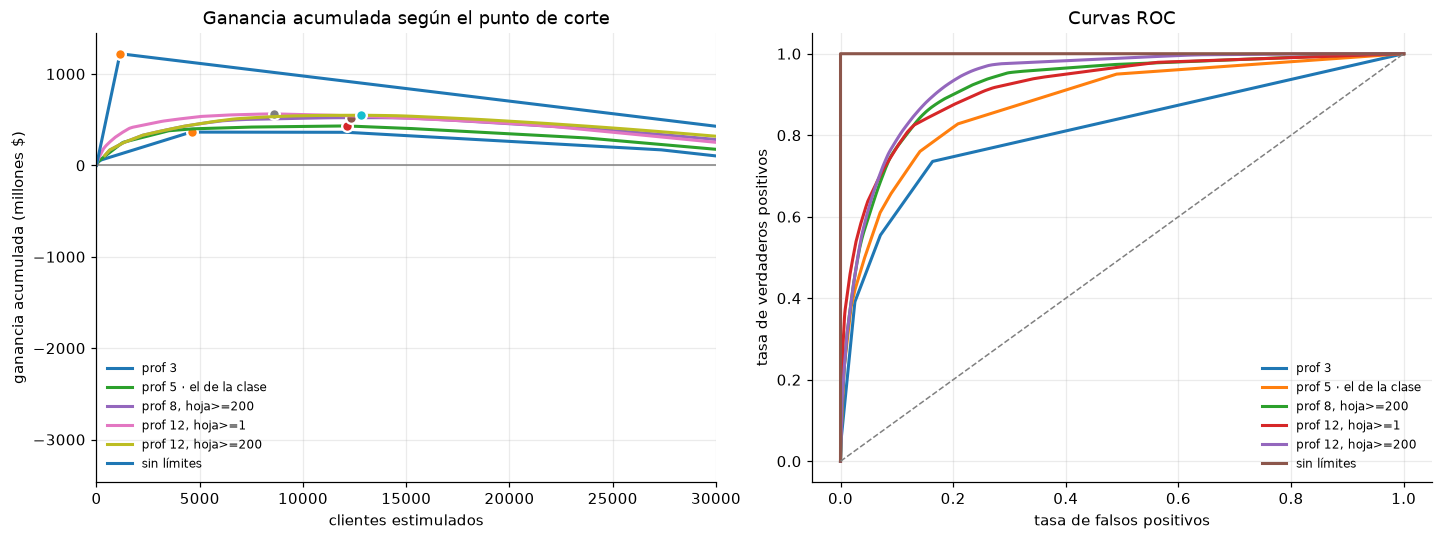

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)

for nombre in GRILLA:
    d = ganancias[nombre]
    ax[0].plot(d["enviados"], d["gan_acumulada"] / 1e6, lw=2, label=nombre)
    j = int(d["gan_acumulada"].idxmax())
    ax[0].plot(d["enviados"].iloc[j], d["gan_acumulada"].iloc[j] / 1e6, "o", ms=7, mec="white", mew=1.5)
ax[0].axhline(0, color="gray", lw=1)
ax[0].set(xlim=(0, 30_000), xlabel="clientes estimulados", ylabel="ganancia acumulada (millones $)",
          title="Ganancia acumulada según el punto de corte")
ax[0].legend(fontsize=8, frameon=False)

for nombre in GRILLA:
    f, t = curvas[nombre]
    ax[1].plot(f, t, lw=2, label=nombre)
ax[1].plot([0, 1], [0, 1], "--", color="gray", lw=1)
ax[1].set(xlabel="tasa de falsos positivos", ylabel="tasa de verdaderos positivos", title="Curvas ROC")
ax[1].legend(fontsize=8, frameon=False, loc="lower right")
plt.show()

**Lo que muestran los gráficos.** A la izquierda, todos los modelos sanos tienen un
máximo interior: estimular de más *destruye* valor, la curva baja y cruza el cero. La
línea del modelo sin límites salta al techo con 1.139 clientes y después se desploma.

A la derecha, su ROC es el ángulo recto perfecto. Cuando una ROC se ve así, la
pregunta no es "qué bueno el modelo" sino "qué se filtró".

## El punto de corte y de dónde sale

Antes de las cuatro métricas que pide la consigna, el corte que importa.

Estimular a un cliente tiene ganancia esperada `p × 1.072.500 − 27.500`. Eso es
positivo cuando:

$$p > \frac{27.500}{1.072.500} = 0,025641$$

Con **2,56%** de probabilidad ya conviene llamar. No hace falta estar seguro: alcanza
con que 1 de cada 39 sea baja.

In [8]:
CORTE_TEORICO = COSTO_ESTIMULO / GANANCIA_ACIERTO
print(f"corte teórico = {CORTE_TEORICO:.6f}")
print("\ncortes empíricos de cada modelo:")
print(res[["modelo", "corte_prob"]].to_string(index=False))

corte teórico = 0.025641

cortes empíricos de cada modelo:
                 modelo  corte_prob
            sin límites    1.000000
       prof 12, hoja>=1    0.025641
     prof 12, hoja>=200    0.025332
      prof 8, hoja>=200    0.025714
prof 5 · el de la clase    0.027451
                 prof 3    0.072917


**Los modelos sanos cortan entre 0,0253 y 0,0283 — encima del valor teórico.** La curva
de ganancia no descubre el umbral: lo **confirma**. Es la respuesta a la pregunta del
notebook original (*¿nota alguna relación con la probabilidad de corte óptima?*).

El único que se desvía fuerte es `prof 3`, y por una razón mecánica: con 8 hojas
ninguna probabilidad cae cerca de 0,0256, así que corta donde puede.

## Las cuatro métricas de la consigna

### Qué se busca

Mostrar que **cada métrica pide un corte distinto**, y que ninguna coincide con el
que le importa al banco.

Las métricas clásicas están construidas asumiendo que los dos tipos de error cuestan
parecido. Acá no: un falso negativo cuesta $1.072.500 y un falso positivo $27.500.

### Cómo lo resuelvo

Sobre la tabla de cortes ya tenemos `TP`, `TN`, `FP` y `FN` acumulados en cada punto.
Las cuatro métricas salen de ahí directo. Agrego una fila inicial que representa
**"no estimular a nadie"**, porque es un corte válido y —spoiler— es el que gana en dos
de las cuatro.

In [9]:
d = tablas["prof 12, hoja>=200"]

m = pd.DataFrame({"prob_baja_2": d["prob_baja_2"], "enviados": d["enviados"]})
m["sensibilidad"]  = d["TP"] / (d["TP"] + d["FN"])          # de los que se van, cuántos agarro
m["especificidad"] = d["TN"] / (d["TN"] + d["FP"])          # de los que se quedan, cuántos dejo en paz
m["precision"]     = d["TP"] / (d["TP"] + d["FP"])
m["accuracy"]      = (d["TP"] + d["TN"]) / (d["TP"] + d["TN"] + d["FP"] + d["FN"])
m["f1"] = 2 * m["precision"] * m["sensibilidad"] / (m["precision"] + m["sensibilidad"])
m["ganancia"] = d["gan_acumulada"]

# corte 0: no estimular a nadie -> todo se predice negativo
tot_e = int(d["TP"].iloc[-1] + d["FN"].iloc[-1])
tot_ne = int(d["FP"].iloc[-1] + d["TN"].iloc[-1])
m = pd.concat([pd.DataFrame([{
    "prob_baja_2": 1.0, "enviados": 0, "sensibilidad": 0.0, "especificidad": 1.0,
    "precision": np.nan, "accuracy": tot_ne / (tot_e + tot_ne), "f1": 0.0, "ganancia": 0.0,
}]), m], ignore_index=True)

optimos = pd.DataFrame([{
    "métrica": met,
    "valor óptimo": m.loc[m[met].idxmax(), met],
    "clientes a estimular": int(m.loc[m[met].idxmax(), "enviados"]),
    "corte": m.loc[m[met].idxmax(), "prob_baja_2"],
    "ganancia": m.loc[m[met].idxmax(), "ganancia"],
} for met in ("accuracy", "sensibilidad", "especificidad", "f1", "ganancia")])
optimos["% de la máxima"] = optimos["ganancia"] / m["ganancia"].max()
optimos.style.format({"valor óptimo": "{:,.4f}", "clientes a estimular": "{:,.0f}",
                      "corte": "{:.4f}", "ganancia": "${:,.0f}", "% de la máxima": "{:.1%}"})

,métrica,valor óptimo,clientes a estimular,corte,ganancia,% de la máxima
0,accuracy,0.9930,0,1.0000,$0,0.0%
1,sensibilidad,1.0000,"143,317",0.0001,"$-2,688,317,500",-490.6%
2,especificidad,1.0000,0,1.0000,$0,0.0%
3,f1,0.2111,"1,324",0.1341,"$249,590,000",45.5%
4,ganancia,"548,020,000.0000","12,832",0.0253,"$548,020,000",100.0%


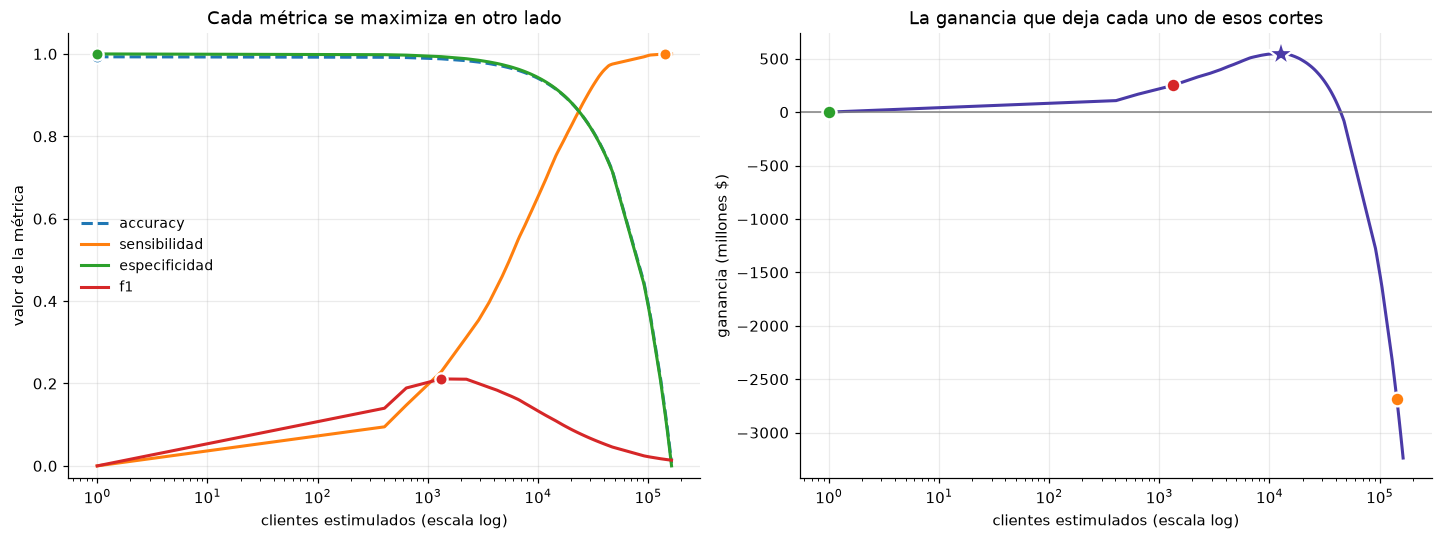

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
x = m["enviados"] + 1                      # +1 para poder usar escala log

for met in ("accuracy", "sensibilidad", "especificidad", "f1"):
    estilo = dict(ls="--") if met == "accuracy" else {}   # si no, queda tapada por especificidad
    linea, = ax[0].plot(x, m[met], lw=2, label=met, **estilo)
    i = int(m[met].idxmax())
    ax[0].plot(x.iloc[i], m[met].iloc[i], "o", ms=8, color=linea.get_color(), mec="white", mew=1.5)
ax[0].set(xscale="log", ylim=(-.03, 1.05), xlabel="clientes estimulados (escala log)",
          ylabel="valor de la métrica", title="Cada métrica se maximiza en otro lado")
ax[0].legend(fontsize=9, frameon=False, loc="center left")

ax[1].plot(x, m["ganancia"] / 1e6, lw=2, color="#4a3aa7")
ax[1].axhline(0, color="gray", lw=1)
for met in ("accuracy", "sensibilidad", "especificidad", "f1"):
    i = int(m[met].idxmax())
    ax[1].plot(x.iloc[i], m["ganancia"].iloc[i] / 1e6, "o", ms=9, mec="white", mew=1.5)
i = int(m["ganancia"].idxmax())
ax[1].plot(x.iloc[i], m["ganancia"].iloc[i] / 1e6, "*", ms=18, color="#4a3aa7", mec="white", mew=1.5)
ax[1].set(xscale="log", xlabel="clientes estimulados (escala log)", ylabel="ganancia (millones $)",
          title="La ganancia que deja cada uno de esos cortes")
plt.show()

### Lo que sale de acá

- **Accuracy se maximiza no estimulando a nadie.** Con 0,70% de eventos, el
  clasificador "nadie se va" acierta el **99,30%**. Cualquier campaña *empeora* la
  accuracy. Si alguien pide optimizar accuracy, está pidiendo no hacer nada.
- **Especificidad, igual**: no llamar a nadie da especificidad perfecta.
- **Sensibilidad se maximiza estimulando a los 143.157** y funde **$2.684 millones**.
- **F1 es la única con óptimo interior**, y aun así deja más de la mitad de la plata:
  corta en 0,134, cinco veces más exigente que el 0,0256 que pide el negocio.
- **Accuracy y especificidad son casi la misma curva** en este dataset — por eso
  accuracy va punteada en el gráfico. Con 0,7% de positivos, los verdaderos negativos
  dominan el numerador de la accuracy y la vuelven una especificidad disfrazada.

**La conclusión de la tarea 1:** en un problema con clases desbalanceadas y costos
asimétricos, la función de ganancia no es una métrica más. Es la única que apunta al
lugar correcto.

---

# Tarea 2 · EDA

> ### Tarea
> Esto es solo el comienzo. Tiene que hacer un video a **Miranda** y para eso debe
> entender bien los datos. Continue con el **EDA**.
>
> * Sume al análisis los periodos descartados
> * ¿Se pueden construir features que den más luz a los modelos a detectar las futuras bajas?

## Parte A · sumar los períodos descartados

### Qué se busca

Hasta acá miramos solo 202104. Hay cosas que **son invisibles en un mes solo** y
aparecen apenas se comparan períodos. La principal: variables que se rompen.

### Cómo lo resuelvo

Para cada variable y cada mes calculo qué porcentaje de filas es nula y qué porcentaje
es cero. Si entre las dos suman prácticamente el 100%, esa variable **no informa nada
ese mes**. Después busco las que están rotas en algunos meses pero vivas en otros: esas
son las peligrosas.

In [11]:
cols = [c for c in cargar(202104, "*").columns
        if c not in ("numero_de_cliente", "foto_mes", "clase_ternaria")]

piezas = []
for c in cols:
    piezas.append(f'avg(case when "{c}" is null then 1.0 else 0.0 end) as "nul__{c}"')
    piezas.append(f'avg(case when "{c}" = 0 then 1.0 else 0.0 end) as "cero__{c}"')

perfil = duckdb.sql(f"select foto_mes, {', '.join(piezas)} from '{PARQUET}' "
                    f"group by foto_mes order by foto_mes").df().set_index("foto_mes")

nulos = perfil[[c for c in perfil if c.startswith("nul__")]].rename(columns=lambda s: s[5:])
ceros = perfil[[c for c in perfil if c.startswith("cero__")]].rename(columns=lambda s: s[6:])
muerta = (nulos + ceros) >= 0.999          # la variable no aporta información ese mes

rotas = muerta.columns[muerta.any() & ~muerta.all()]     # rota en algún mes, viva en otro
print("VARIABLES QUE SE ROMPEN EN ALGÚN MES\n")
print(muerta[rotas].T.replace({True: "ROTA", False: "ok"}).to_string())
print("\nMuertas en los 6 meses (descartables):", list(muerta.columns[muerta.all()]))

VARIABLES QUE SE ROMPEN EN ALGÚN MES

foto_mes         202103 202104 202105 202106 202107 202108
mpayroll2          ROTA   ROTA   ROTA     ok   ROTA   ROTA
cpayroll2_trx      ROTA   ROTA   ROTA     ok   ROTA   ROTA
ccajas_depositos     ok     ok   ROTA     ok     ok     ok

Muertas en los 6 meses (descartables): ['mcuenta_corriente_adicional', 'Master_madelantodolares', 'Visa_madelantodolares']


### Lo que muestra

**`mpayroll2` y `cpayroll2_trx` existen solo en 202106.** En los otros cinco meses están
vacías. Un modelo entrenado en 202106 aprendería a usarlas, y en producción no van a
estar. Esto es **data drifting**, y es el tipo de cosa que hunde un modelo en el
privado sin que se note en el público.

**`ccajas_depositos` se cae justo en 202105.**

Y tres variables están muertas en los seis meses: son columnas que ocupan lugar y no
dicen nada.

## Parte B · qué separa a un BAJA+2

### Qué se busca

Entender el fenómeno antes de modelarlo. Si el cliente que se va tiene un
comportamiento reconocible, eso es lo que hay que contarle a Miranda — y además indica
qué features tiene sentido construir después.

### Cómo lo resuelvo

Calculo el **AUC univariado** de cada variable: usando *solo esa variable* para ordenar
clientes, ¿cuán bien separa los `BAJA+2`? Se puede calcular como el estadístico de
Mann-Whitney, que es rangos y no requiere entrenar nada.

Lo importante es leer **la dirección**:

- **AUC > 0,5** → la variable **sube** cuando el cliente se va
- **AUC < 0,5** → la variable **baja** cuando el cliente se va

Los nulos los dejo afuera del cálculo a propósito, y los analizo aparte — porque
resultan ser señal por sí mismos.

In [12]:
d04 = cargar(202104)
es_baja2 = (d04["clase_ternaria"] == "BAJA+2").astype(int).to_numpy()
tasa_base = es_baja2.mean()

def auc_univariada(x, y):
    """AUC de Mann-Whitney sobre los valores no nulos."""
    ok = ~pd.isna(x)
    if ok.sum() < 100 or y[ok].sum() < 10 or len(np.unique(x[ok])) < 2:
        return np.nan
    r = pd.Series(x[ok]).rank().to_numpy()
    yy = y[ok]
    n1, n0 = yy.sum(), len(yy) - yy.sum()
    return (r[yy == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)

filas = []
for c in cols:
    x = pd.to_numeric(d04[c], errors="coerce").to_numpy(dtype=float)
    a = auc_univariada(x, es_baja2)
    pct_nul = float(pd.isna(x).mean())
    filas.append({"variable": c, "auc": a, "fuerza": abs(a - .5) if a == a else np.nan,
                  "pct_nulos": pct_nul,
                  "tasa_baja2_si_nulo": float(es_baja2[pd.isna(x)].mean()) if pct_nul else np.nan})

uni = pd.DataFrame(filas).sort_values("fuerza", ascending=False)
uni["dirección"] = np.where(uni["auc"] > .5, "SUBE al irse", "BAJA al irse")
uni.head(12)[["variable", "auc", "fuerza", "dirección"]].style.format({"auc": "{:.4f}", "fuerza": "{:.4f}"})

,variable,auc,fuerza,dirección
105,ctrx_quarter,0.1435,0.3565,BAJA al irse
16,mcaja_ahorro,0.1822,0.3178,BAJA al irse
9,mpasivos_margen,0.2004,0.2996,BAJA al irse
26,mtarjeta_visa_consumo,0.2075,0.2925,BAJA al irse
25,ctarjeta_visa_transacciones,0.2103,0.2897,BAJA al irse
20,mcuentas_saldo,0.2278,0.2722,BAJA al irse
23,mautoservicio,0.2326,0.2674,BAJA al irse
22,ctarjeta_debito_transacciones,0.2357,0.2643,BAJA al irse
71,ccomisiones_otras,0.2399,0.2601,BAJA al irse
136,Visa_msaldopesos,0.2508,0.2492,BAJA al irse


**Casi todas las variables importantes tienen AUC < 0,5: el cliente que se va se apaga.**
Deja de transaccionar, vacía la caja de ahorro, deja de consumir con la tarjeta.

La excepción vale oro: **`mactivos_margen` tiene AUC 0,718 — sube**. Se endeuda más
antes de irse. Apagarse y endeudarse son dos caminos distintos hacia la misma baja.

Miremos la más fuerte, `ctrx_quarter`, en detalle:

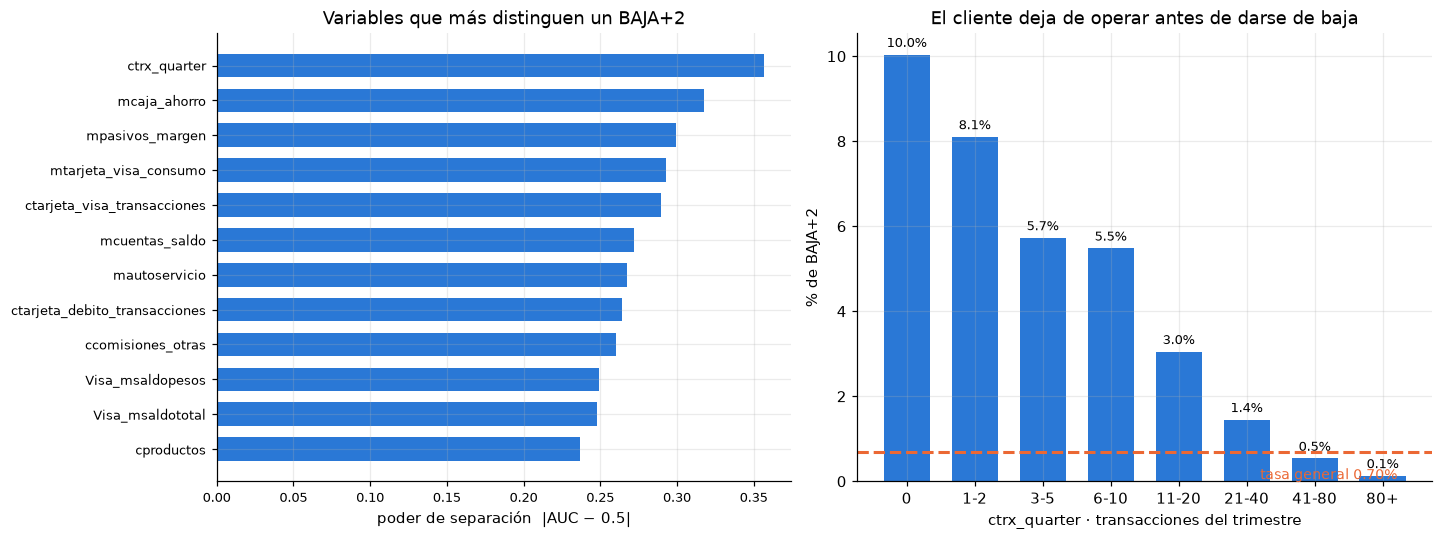

,clientes,tasa_baja2,lift
tramo,,,
0,"1,684",10.04%,14.4×
1-2,790,8.10%,11.6×
3-5,"1,380",5.72%,8.2×
6-10,"2,628",5.48%,7.9×
11-20,"5,547",3.05%,4.4×
21-40,"13,812",1.45%,2.1×
41-80,"33,545",0.54%,0.8×
80+,"103,898",0.13%,0.2×


In [13]:
d04["tramo"] = pd.cut(d04["ctrx_quarter"], bins=[-1, 0, 2, 5, 10, 20, 40, 80, 10_000],
                      labels=["0", "1-2", "3-5", "6-10", "11-20", "21-40", "41-80", "80+"])
g = d04.assign(baja2=es_baja2).groupby("tramo", observed=True).agg(
    clientes=("baja2", "size"), tasa_baja2=("baja2", "mean"))
g["lift"] = g["tasa_baja2"] / tasa_base

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)

top = uni.head(12).iloc[::-1]
ax[0].barh(top["variable"], top["fuerza"], color="#2a78d6", height=.68)
ax[0].set(xlabel="poder de separación  |AUC − 0.5|", title="Variables que más distinguen un BAJA+2")
ax[0].tick_params(labelsize=8.5)

barras = ax[1].bar(g.index.astype(str), g["tasa_baja2"] * 100, color="#2a78d6", width=.68)
ax[1].bar_label(barras, labels=[f"{v:.1f}%" for v in g["tasa_baja2"] * 100], padding=3, fontsize=8.5)
ax[1].axhline(tasa_base * 100, color="#eb6834", lw=2, ls="--")
ax[1].annotate(f"tasa general {tasa_base:.2%}", (5.2, tasa_base * 100), xytext=(0, -18),
               textcoords="offset points", color="#eb6834", fontsize=9)
ax[1].set(xlabel="ctrx_quarter · transacciones del trimestre", ylabel="% de BAJA+2",
          title="El cliente deja de operar antes de darse de baja")
plt.show()

g.style.format({"clientes": "{:,.0f}", "tasa_baja2": "{:.2%}", "lift": "{:.1f}×"})

**Con cero transacciones en el trimestre, el 10,04% se da de baja — 14,4 veces la tasa
general.** Y la relación es monótona: cuanto más opera, menos riesgo. Es el hallazgo
más presentable de todo el EDA, porque es accionable: el cliente todavía está cuando
se apaga.

## Parte C · los nulos como señal

### Qué se busca

El notebook original pregunta por los missing values y avisa que su tratamiento *"es
uno de los temas que navegarán en los experimentos colectivos"*. Vale la pena mirar si
el dato faltante es ruido o información.

### Cómo lo resuelvo

Para cada variable con nulos, comparo la tasa de `BAJA+2` **entre los que tienen el
dato faltante** contra la tasa general.

In [14]:
nul = uni[uni["pct_nulos"].between(.01, .99)].copy()
nul["lift"] = nul["tasa_baja2_si_nulo"] / tasa_base
print(f"tasa general de BAJA+2: {tasa_base:.4%}\n")
nul.sort_values("lift", ascending=False).head(8)[
    ["variable", "pct_nulos", "tasa_baja2_si_nulo", "lift"]
].style.format({"pct_nulos": "{:.2%}", "tasa_baja2_si_nulo": "{:.2%}", "lift": "{:.2f}×"})

tasa general de BAJA+2: 0.6976%



,variable,pct_nulos,tasa_baja2_si_nulo,lift
136,Visa_msaldopesos,4.89%,3.84%,5.51×
135,Visa_msaldototal,4.89%,3.84%,5.51×
151,Visa_mpagominimo,4.89%,3.84%,5.51×
147,Visa_fechaalta,4.89%,3.84%,5.51×
130,Visa_delinquency,4.89%,3.84%,5.51×
144,Visa_mpagado,4.89%,3.84%,5.51×
131,Visa_status,4.89%,3.84%,5.51×
137,Visa_msaldodolares,4.89%,3.84%,5.51×


### Lo que muestra

**El 4,89% de los clientes tiene todo el bloque `Visa_*` en null** — o sea, no tiene
tarjeta Visa. Entre ellos la tasa de baja es **3,84% contra 0,70% general: lift 5,5×**.

**El dato faltante *es* la señal.** Si se imputa con la mediana, se borra.

Doce variables `Visa_*` comparten exactamente el mismo patrón, porque el nulo viene del
mismo hecho. Un solo flag las resume.

## Parte D · ¿se pueden construir features?

### Qué se busca

La consigna pregunta si se pueden construir features que ayuden. La parte B da la
pista: el cliente **se apaga**. Si eso es cierto, lo que debería predecir no es el
*nivel* de actividad sino la *caída* — un cliente que siempre hizo 5 transacciones no
es lo mismo que uno que hacía 50 y ahora hace 5.

Eso el modelo no lo puede ver, porque solo mira la foto de un mes.

### Cómo lo resuelvo

Con funciones de ventana, las mismas de `z101`, pero sobre las variables en vez de
sobre la presencia del cliente:

- **`lag1`** — el valor del mes pasado
- **`delta1`** — la variación contra el mes pasado
- **`vs_hist`** — el valor de hoy contra su propio promedio de los 3 meses previos.
  Menor que 1 significa "está por debajo de lo que este cliente suele hacer"
- **`sin_visa` / `sin_master` / `tarjetas_faltantes`** — el hallazgo de la parte C,
  hecho variable

`vs_hist` es un ratio, así que hay que cuidarse de la división por cero: va con
`nullif`.

In [15]:
CLAVE = ["ctrx_quarter", "mcaja_ahorro", "mpasivos_margen", "mtarjeta_visa_consumo",
         "mcuentas_saldo", "cproductos", "mpayroll", "chomebanking_transacciones",
         "mrentabilidad", "mactivos_margen"]
ROTAS = ["mpayroll2", "cpayroll2_trx", "ccajas_depositos",
         "mcuenta_corriente_adicional", "Master_madelantodolares", "Visa_madelantodolares"]

base_cols = [c for c in cols if c not in ROTAS]
vent = "over (partition by numero_de_cliente order by foto_mes"

nuevas = []
for v in CLAVE:
    nuevas += [
        f'lag("{v}", 1) {vent}) as "{v}__lag1"',
        f'"{v}" - lag("{v}", 1) {vent}) as "{v}__delta1"',
        f'"{v}" / nullif(avg("{v}") {vent} rows between 3 preceding and 1 preceding), 0) as "{v}__vs_hist"',
    ]
nuevas += [
    "case when Visa_status is null then 1 else 0 end as sin_visa",
    "case when Master_status is null then 1 else 0 end as sin_master",
    "(case when Visa_status is null then 1 else 0 end + "
    " case when Master_status is null then 1 else 0 end) as tarjetas_faltantes",
]

con_hist = duckdb.sql(f"""
    with h as (
        select numero_de_cliente, foto_mes, clase_ternaria
             , {', '.join(f'"{c}"' for c in base_cols)}
             , {', '.join(nuevas)}
        from '{PARQUET}'
    ) select * from h where foto_mes = 202104
""").df()

nuevas_cols = [c for c in con_hist.columns
               if c not in base_cols + ["numero_de_cliente", "foto_mes", "clase_ternaria"]]
print(f"{len(base_cols)} variables originales + {len(nuevas_cols)} construidas")

146 variables originales + 33 construidas


Ahora, ¿el árbol las usa? Entreno con todo junto y miro la importancia de variables:

In [16]:
usar = base_cols + nuevas_cols
mod = DecisionTreeClassifier(criterion="gini", random_state=SEMILLA, max_depth=12,
                             min_samples_split=1000, min_samples_leaf=200
                             ).fit(con_hist[usar], con_hist["clase_ternaria"])

imp = (pd.DataFrame({"variable": usar, "importancia": mod.feature_importances_})
       .query("importancia > 0").sort_values("importancia", ascending=False))
imp["construida"] = np.where(imp["variable"].isin(nuevas_cols), "sí", "")

print(f"las {len(nuevas_cols)} features construidas se llevan el "
      f"{imp.loc[imp.construida == 'sí', 'importancia'].sum():.1%} de la importancia total\n")
imp.head(12).style.format({"importancia": "{:.4f}"}).hide(axis="index")

las 33 features construidas se llevan el 15.3% de la importancia total



variable,importancia,construida
ctrx_quarter,0.3231,
Master_status,0.1673,
mcuentas_saldo,0.1294,
tarjetas_faltantes,0.0925,sí
mprestamos_personales,0.0863,
cproductos__vs_hist,0.0250,sí
mrentabilidad_annual,0.0235,
Master_Fvencimiento,0.0176,
mtarjeta_visa_consumo,0.0173,
ctrx_quarter__vs_hist,0.0142,sí


### Lo que muestra, y lo que todavía no se puede saber

El árbol **sí usa** algunas de las construidas — sobre todo `tarjetas_faltantes`, que
es el hallazgo de los nulos convertido en variable, y algunos `vs_hist`.

Pero acá hay que ser honesta sobre el límite: **que el árbol las use no significa que
mejoren nada**. Toda la medición de este notebook está hecha sobre los mismos datos con
los que el modelo entrenó — es exactamente el mecanismo que hizo que el árbol sin
límites pareciera perfecto en la tarea 1.

Para saber si estas features **realmente ayudan**, hay que medir la ganancia en un mes
que el modelo no haya visto. Eso es lo que viene en `z301_Sobre_la_incertidumbre`, y
por eso lo dejo planteado y no resuelto acá.

El script `06_features.py`, al lado de este notebook, tiene esa medición hecha por
adelantado. Adelanto el resultado por si sirve: **con un solo árbol, las features de
historia no mejoran nada** (−1,3% en un mes, +1,6% en otro: ruido). El único aporte
real es `tarjetas_faltantes`.

---

# Resumen

**Tarea 1**

| pregunta | respuesta |
|---|---|
| ¿Más ganancia? | El árbol sin límites: $1.221.577.500 — pero porque memorizó |
| ¿Peor ganancia? | `prof 3`, con 8 hojas: $363.962.500 |
| ¿Mayor AUC? | El mismo sin límites: 1,0000 — la señal de alarma |
| ¿Peor AUC? | `prof 3`: 0,8127 |
| Mejor modelo real | `prof 12, hoja>=200` — mejor AUC con la mitad de hojas |

Punto de corte óptimo por métrica:

| métrica | clientes a estimular | ganancia |
|---|---|---|
| accuracy | 0 | $0 |
| especificidad | 0 | $0 |
| sensibilidad | 143.157 | −$2.683.917.500 |
| F1 | 1.324 | 45,5% de la máxima |
| **ganancia** | **12.832** | **$548.020.000** |

**Tarea 2**

- `mpayroll2` y `cpayroll2_trx` viven **solo en 202106** — data drifting
- No tener tarjeta Visa: **lift 5,5×**. El nulo es señal, imputarlo la borra
- Sin transacciones en el trimestre: **lift 14,4×**
- `mactivos_margen` sube al irse: hay quien **se endeuda** antes de la baja
- Las features de historia se pueden construir, pero para saber si sirven falta `z301`

**Para el video de Miranda**

1. El cliente se apaga antes de irse — hay ventana para actuar
2. No tener tarjeta Visa multiplica por 5,5 el riesgo, y es un flag, no un modelo
3. La campaña conviene con p > 2,56%, y eso sale de la aritmética del negocio
4. Optimizar accuracy sería no llamar a nadie